In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [3]:
# IMPUTATION - Handling Missing values
from sklearn.impute import SimpleImputer, KNNImputer

# PREPROCESSING - Scaling --> Converting the numerical values to same unit
# Encoding: --> Converting categorical values to numerical values
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,LabelEncoder, OneHotEncoder, OrdinalEncoder, PolynomialFeatures)

# PIPELINE & TRANSFORMERS
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer

# DATA SPLITTING & CROSS-VALIDATION
from sklearn.model_selection import (train_test_split, KFold, cross_val_score, cross_validate, cross_val_predict, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RandomizedSearchCV)

# FEATURE SELECTION
from sklearn.feature_selection import (SelectKBest, SelectPercentile, VarianceThreshold, RFE, RFECV, SequentialFeatureSelector, SelectFromModel,
mutual_info_regression)

from sklearn.inspection import permutation_importance

# FEATURE EXTRACTION
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer

# REGRESSION MODELS
#Linear model
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor, HuberRegressor)

#tree model
from sklearn.tree import DecisionTreeRegressor

#Ensemble model
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor, VotingRegressor, HistGradientBoostingRegressor)

#SVM
from sklearn.svm import SVR

#KNN
from sklearn.neighbors import KNeighborsRegressor

#Base line model
from sklearn.dummy import DummyRegressor

#High-performance gradient boosting frameworks
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# METRICS for Regression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error)

#Classification models:
#Linear model
from sklearn.linear_model import (LogisticRegression, SGDClassifier, Perceptron, PassiveAggressiveClassifier)

#tree model
from sklearn.tree import DecisionTreeClassifier

#Ensemble model
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier,
    BaggingClassifier, VotingClassifier, StackingClassifier,
    HistGradientBoostingClassifier)

#Neural network
from sklearn.neural_network import MLPClassifier

#Naive bayes
from sklearn.naive_bayes import (GaussianNB, MultinomialNB, BernoulliNB,    CategoricalNB)

#KNN
from sklearn.neighbors import KNeighborsClassifier

#SVM
from sklearn.svm import SVC, LinearSVC

#Base line
from sklearn.dummy import DummyClassifier

#XGBoost (External Library)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics for Classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

#Creating random dataset for Regression and Classification
from sklearn.datasets import make_classification, make_regression

# Imbalance dataset and adjusting dataset for sampling count
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

#Data Manipulation
import numpy as np
import pandas as pd
from scipy import stats

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
#from sentence_transformers import SentenceTransformer 

In [4]:
train_df=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
train_df.head(1)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2


In [18]:
train_df['disability'].value_counts()

disability
False    195257
True       2743
Name: count, dtype: int64

In [9]:
train_df.isna().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
disability      0
comment         0
label           0
dtype: int64

In [19]:
train_df=train_df.drop(columns=['race','religion','gender'], axis=1)

In [20]:
train_df=train_df.dropna()

In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197999 entries, 0 to 197999
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  197999 non-null  object
 1   post_id       197999 non-null  int64 
 2   emoticon_1    197999 non-null  int64 
 3   emoticon_2    197999 non-null  int64 
 4   emoticon_3    197999 non-null  int64 
 5   upvote        197999 non-null  int64 
 6   downvote      197999 non-null  int64 
 7   if_1          197999 non-null  int64 
 8   if_2          197999 non-null  int64 
 9   disability    197999 non-null  bool  
 10  comment       197999 non-null  object
 11  label         197999 non-null  int64 
dtypes: bool(1), int64(9), object(2)
memory usage: 18.3+ MB


In [22]:
X=train_df.drop(columns=['created_date','label'], axis=1)
y=train_df['label']
print(X.shape)
print(y.shape)

(197999, 10)
(197999,)


In [23]:
test_df=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
test_df.head(2)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel


In [8]:
test_df.isna().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [19]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   post_id     102000 non-null  int64 
 1   emoticon_1  102000 non-null  int64 
 2   emoticon_2  102000 non-null  int64 
 3   emoticon_3  102000 non-null  int64 
 4   upvote      102000 non-null  int64 
 5   downvote    102000 non-null  int64 
 6   if_1        102000 non-null  int64 
 7   if_2        102000 non-null  int64 
 8   disability  102000 non-null  bool  
 9   comment     102000 non-null  object
dtypes: bool(1), int64(8), object(1)
memory usage: 7.1+ MB


In [24]:
test_df=test_df.drop(columns=['created_date','race','religion','gender'], axis=1)

In [25]:
sample_submission=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
sample_submission.head(3)

,ID,label
0,1,0
1,2,0
2,3,0


In [26]:
print(X.shape)
print(test_df.shape)
print(sample_submission.shape)

(197999, 10)
(102000, 10)
(102000, 2)


<Axes: >

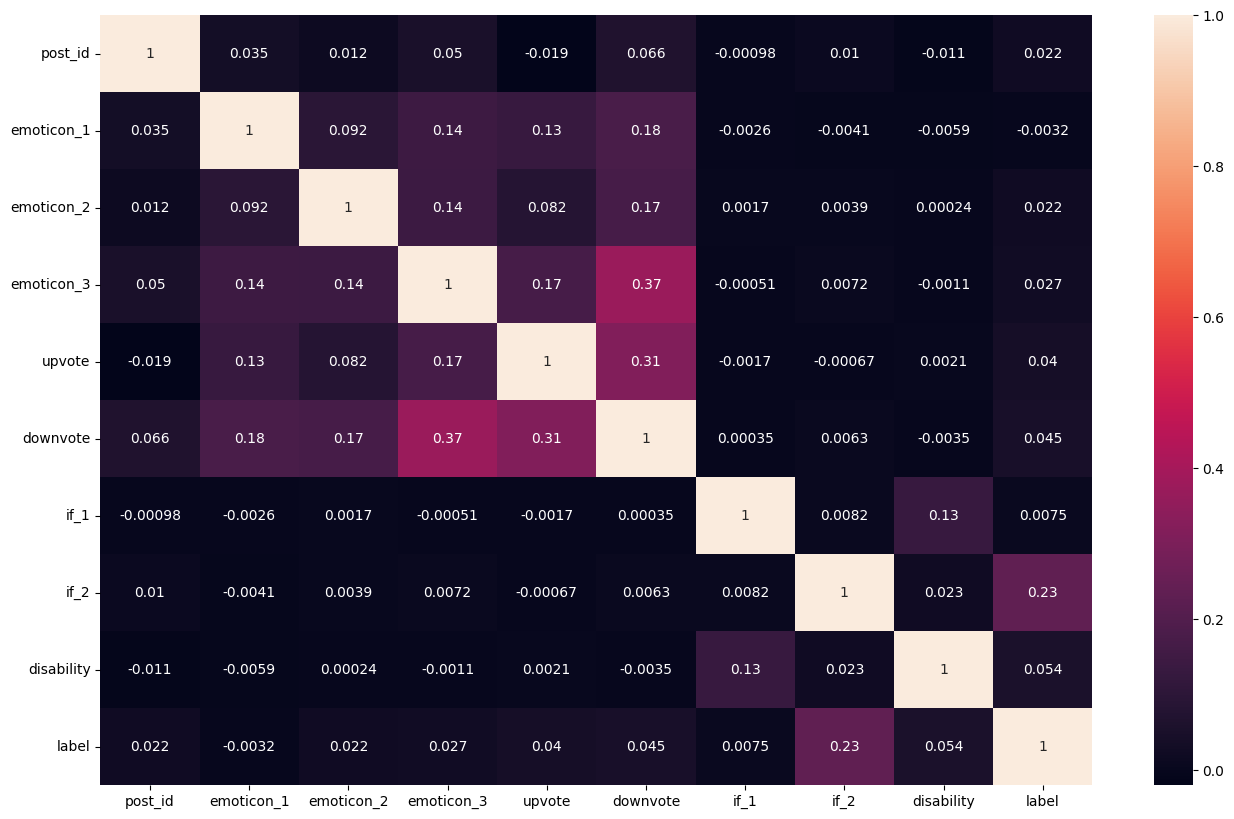

In [16]:
plt.figure(figsize=(16,10))
cor_mat=train_df.corr(numeric_only=True)
sns.heatmap(cor_mat, annot=True)

In [41]:
y.value_counts()

label
0    114172
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [43]:
classes = np.unique(y_train)
classes

array([0, 1, 2, 3])

In [44]:
class_weights = compute_class_weight(
    class_weight='balanced',  # #Compute balanced class weights
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))  # #Convert class weights to a dictionary {class: weight}
print(class_weights)

{np.int64(0): np.float64(0.43355448068501207), np.int64(1): np.float64(3.1096812001875294), np.int64(2): np.float64(0.7927512848093702), np.int64(3): np.float64(9.051514737991265)}


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1001)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(158399, 10)
(39600, 10)
(158399,)
(39600,)


In [48]:
y_test.value_counts()

label
0    22905
2    12503
1     3135
3     1057
Name: count, dtype: int64

In [28]:
numeric_selector = X_train.select_dtypes(exclude=['object']).columns.tolist()
categorical_selector='comment'
categorical_selector
# make_column_selector(dtype_include=["int64", "float64"])
# categorical_selector = make_column_selector(dtype_include=["object", "bool"])

'comment'

In [15]:
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


In [34]:
# text_transformer = Pipeline(steps=[
#     ('tfidf', TfidfVectorizer(lowercase=True, token_pattern=r'(?u)\b[a-zA-Z]+\b',
#                               max_features=40000, ngram_range=(1, 2), stop_words='english'))
# ])

text_transformer = Pipeline(steps=[
    ("text", TfidfVectorizer(max_features=20000,ngram_range=(1, 2),
            stop_words="english"))])

# Numeric: Impute missing with median, then scale
numeric_transformer = Pipeline(steps=[("num", StandardScaler())])

# Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ('text', text_transformer, categorical_selector),
    ('num', numeric_transformer, numeric_selector)
])  # Pass through any other columns

# , remainder='passthrough'
# full_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('selector', SelectKBest('chi2', k=3000))])
# full_pipeline


In [32]:
# X_train_processed = full_pipeline.fit_transform(X_train, y_train)
# X_test_processed = full_pipeline.transform(X_test)
# test_df_processed = full_pipeline.transform(test_df)

In [21]:
feature_names = full_pipeline.named_steps['selector'].get_feature_names_out()
feature_names

array(['x45', 'x46', 'x60', ..., 'x30006', 'x30007', 'x30008'],
      dtype=object)

In [22]:
X_train_df = pd.DataFrame.sparse.from_spmatrix(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame.sparse.from_spmatrix(X_test_processed, columns=feature_names)
test_final_df = pd.DataFrame.sparse.from_spmatrix(test_df_processed, columns=feature_names)

In [19]:
lin_reg=LogisticRegression(max_iter=1000, class_weight="balanced")
lin_reg.fit(X_train_df, y_train)
y_pred=lin_reg.predict(X_test_df)
cls_report=classification_report(y_test, y_pred, digits=3)
print("="*60)
print(cls_report)

              precision    recall  f1-score   support

           0      0.874     0.797     0.834     25118
           1      0.562     0.814     0.665      3502
           2      0.787     0.722     0.753     13737
           3      0.302     0.757     0.432      1203

    accuracy                          0.773     43560
   macro avg      0.631     0.772     0.671     43560
weighted avg      0.806     0.773     0.784     43560



In [23]:
xgb_model=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
xgb_model.fit(X_train_df, y_train)
y_pred=xgb_model.predict(X_test_df)
cls_report=classification_report(y_test, y_pred, digits=3)
print("="*60)
print(cls_report)

              precision    recall  f1-score   support

           0      0.977     0.947     0.962     25118
           1      0.796     0.731     0.762      3502
           2      0.827     0.925     0.873     13737
           3      0.734     0.399     0.517      1203

    accuracy                          0.907     43560
   macro avg      0.834     0.750     0.779     43560
weighted avg      0.909     0.907     0.906     43560



In [35]:
conf_mat=confusion_matrix(y_test, y_pred)
print(conf_mat)

[[23780   138  1143    57]
 [   37  2561   873    31]
 [  479   468 12704    86]
 [   34    49   640   480]]


In [23]:
lgbm_model=LGBMClassifier(random_state=42, class_weight='balanced')
lgbm_model.fit(X_train_df, y_train)
y_pred=lgbm_model.predict(X_test_df)
cls_report=classification_report(y_test, y_pred, digits=3)
print("="*60)
print(cls_report)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.388634 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 207917
[LightGBM] [Info] Number of data points in the train set: 132659, number of used features: 2504
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
              precision    recall  f1-score   support

           0      0.979     0.942     0.960     37677
           1      0.684     0.856     0.760      5253
           2      0.890     0.824     0.856     20605
           3      0.408     0.775     0.534      1805

    accuracy                          0.893     65340
   macro avg      0.740     0.849     0.778     65340
weighted avg      0.911     0.893     0.899     65340



In [86]:
# text_transformer = Pipeline(
#     steps=[
#         ("tfidf", TfidfVectorizer(
#             max_features=20000,  # tune as needed
#             ngram_range=(1, 2),min_df=3,max_df=0.95,sublinear_tf=True))])

# numeric_transformer = Pipeline(
#     steps=[("scaler", MinMaxScaler())])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("text", text_transformer, categorical_selector),
#         ("num", numeric_transformer, numeric_selector)])

# X_train_processed=preprocessor.fit_transform(X_train)
# X_test_processed=preprocessor.transform(X_test)
# test_df_final=preprocessor.transform(test_df)

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True
        ), categorical_selector),
        ("num", MinMaxScaler(), numeric_selector)
    ]
)

# X_train_processed=preprocessor.fit_transform(X_train)
# X_test_processed=preprocessor.transform(X_test)
# test_df_final=preprocessor.transform(test_df)

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD

model = Pipeline([
    ("preprocessor", preprocessor),
    ("LGBM",LGBMClassifier(random_state=42, class_weight='balanced'))
])
    # ("oversample", RandomOverSampler(random_state=42)),
    # ('selector', SelectKBest(chi2, k=2000)),
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
cls_report=classification_report(y_test, y_pred)
print("="*60)
print(cls_report)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 26.805507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1524201
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 20009
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


KeyboardInterrupt: 

In [1]:
from sklearn.linear_model import LogisticRegression

In [55]:
from sklearn.decomposition import TruncatedSVD
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("svd", TruncatedSVD(n_components=800, random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ("lgbm",LGBMClassifier(random_state=42, class_weight='balanced'))
])

model.fit(X_train, y_train)
y_pred=model.predict(X_test)
cls_report=classification_report(y_test, y_pred)
print("="*60)
print(cls_report)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.437490 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 204000
[LightGBM] [Info] Number of data points in the train set: 365068, number of used features: 800
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
              precision    recall  f1-score   support

           0       0.75      0.71      0.73     22905
           1       0.52      0.69      0.59      3135
           2       0.60      0.54      0.57     12503
           3       0.23      0.55      0.32      1057

    accuracy                           0.65     39600
   macro avg       0.52      0.62      0.55     39600
weighted avg       0.67      0.65      0.65     39600



In [23]:
from sklearn.feature_selection import SelectKBest, chi2

model = Pipeline([
    ("preprocessor", preprocessor),
    ("svd", TruncatedSVD(n_components=1000, random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ("Log_reg",LogisticRegression(max_iter=3000,n_jobs=-1))])

    # ("oversample", RandomOverSampler(random_state=42)),
    # ('selector', SelectKBest(chi2, k=2000)),
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
cls_report=classification_report(y_test, y_pred)
print("="*60)
print(cls_report)

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22858
           1       0.81      0.70      0.75      3095
           2       0.84      0.92      0.88     12527
           3       0.78      0.44      0.56      1120

    accuracy                           0.90     39600
   macro avg       0.85      0.75      0.79     39600
weighted avg       0.90      0.90      0.90     39600



In [40]:
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

model = Pipeline([
    ("preprocessor", preprocessor),
    ("svd", TruncatedSVD(n_components=500, random_state=42)),
    ("log_reg", LogisticRegression(max_iter=3000, n_jobs=-1))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22858
           1       0.80      0.64      0.71      3095
           2       0.80      0.91      0.85     12527
           3       0.72      0.30      0.43      1120

    accuracy                           0.89     39600
   macro avg       0.82      0.70      0.74     39600
weighted avg       0.89      0.89      0.89     39600



In [111]:
print(type(categorical_selector))
print(categorical_selector)

print(X_train[categorical_selector].shape)
print(X_train[numeric_selector].shape)

<class 'str'>
comment
(154439,)
(154439, 9)


In [112]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['text__00', 'text__000', 'text__000 00', ..., 'num__if_1',
       'num__if_2', 'num__disability'], dtype=object)

In [ ]:
X_train_processed.toarray()

In [113]:
X_train_df = pd.DataFrame.sparse.from_spmatrix(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)
X_train_df.head(3)

,text__00,text__000,text__000 00,text__000 000,text__000 for,text__000 in,text__000 people,text__000 per,text__000 to,text__000 year,...,text__zuma,num__post_id,num__emoticon_1,num__emoticon_2,num__emoticon_3,num__upvote,num__downvote,num__if_1,num__if_2,num__disability
60710,0,0,0,0,0,0,0,0,0,0,...,0,0.477064,0,0,0,0.00995,0,0,0.000546,0
138544,0,0,0,0,0,0,0,0,0,0,...,0,0.183486,0,0,0,0,0,0,0.000546,0
195215,0,0,0,0,0,0,0,0,0,0,...,0,0.174312,0,0,0,0,0,0,0.003825,0


In [114]:
X_test_df = pd.DataFrame.sparse.from_spmatrix(
    X_test_processed,
    columns=feature_names,
    index=X_test.index)
X_test_df.head(3)

,text__00,text__000,text__000 00,text__000 000,text__000 for,text__000 in,text__000 people,text__000 per,text__000 to,text__000 year,...,text__zuma,num__post_id,num__emoticon_1,num__emoticon_2,num__emoticon_3,num__upvote,num__downvote,num__if_1,num__if_2,num__disability
60289,0,0,0,0,0,0,0,0,0,0,...,0,0.477064,0,0,0,0,0,0,0.003825,0
52249,0,0,0,0,0,0,0,0,0,0,...,0,0.477064,0.06383,0,0.117647,0.049751,0.028037,0.005376,0.000546,0
141400,0,0,0,0,0,0,0,0,0,0,...,0,0.477064,0,0,0,0.00995,0,0.003226,0.001639,1.0


In [115]:
test_data = pd.DataFrame.sparse.from_spmatrix(
    test_df_final,
    columns=feature_names,
    index=test_df.index)
test_data.head(3)

,text__00,text__000,text__000 00,text__000 000,text__000 for,text__000 in,text__000 people,text__000 per,text__000 to,text__000 year,...,text__zuma,num__post_id,num__emoticon_1,num__emoticon_2,num__emoticon_3,num__upvote,num__downvote,num__if_1,num__if_2,num__disability
0,0,0,0,0,0,0,0,0,0,0,...,0,0.477064,0.042553,0,0,0.0199,0.009346,0,0.003825,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0.944954,0,0,0,0,0,0,0.003825,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0.917431,0,0,0,0.014925,0,0,0.000546,0


In [45]:
# X_train_df=pd.DataFrame(X_train_processed.toarry(), columns=feature_names, index=X_train.index)
# X_test_df=pd.DataFrame(X_test_processed.toarry(), columns=feature_names, index=X_test.index)

In [116]:
print(X_train_df.shape)
print(X_test_df.shape)
print(y_train.shape)
print(y_test.shape)
print(test_data.shape)

(154439, 20009)
(43560, 20009)
(154439,)
(43560,)
(102000, 20009)


In [100]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=10000)
X_train_sel = selector.fit_transform(X_train_df, y_train)
X_test_sel  = selector.transform(X_test_df)
test_data_sel=selector.transform(test_data)

In [102]:
print(X_train_sel.shape)
print(X_test_sel.shape)
print(y_train.shape)
print(y_test.shape)
print(test_data_sel.shape)

(148499, 10000)
(49500, 10000)
(148499,)
(49500,)
(102000, 10000)


In [118]:
lin_reg=LogisticRegression(max_iter=1000, class_weight="balanced")
lin_reg.fit(X_train_df, y_train)
y_pred=lin_reg.predict(X_test_df)
cls_report=classification_report(y_test, y_pred, digits=3)
print("="*60)
print(cls_report)

              precision    recall  f1-score   support

           0      0.869     0.798     0.832     25118
           1      0.581     0.801     0.674      3502
           2      0.763     0.727     0.744     13737
           3      0.330     0.704     0.450      1203

    accuracy                          0.773     43560
   macro avg      0.636     0.758     0.675     43560
weighted avg      0.797     0.773     0.781     43560



In [119]:
Lin_SVC=LinearSVC(C=1.0, class_weight="balanced")
Lin_SVC.fit(X_train_df, y_train)
y_pred=Lin_SVC.predict(X_test_df)
cls_report=classification_report(y_test, y_pred)
print("="*60)
print("model_name:", model_name)
print(cls_report)

model_name: gradient_boosting
              precision    recall  f1-score   support

           0       0.84      0.85      0.84     25118
           1       0.62      0.72      0.67      3502
           2       0.78      0.70      0.74     13737
           3       0.42      0.54      0.48      1203

    accuracy                           0.78     43560
   macro avg       0.66      0.71      0.68     43560
weighted avg       0.79      0.78      0.79     43560



In [120]:
models = {
    #"log_reg": LogisticRegression(max_iter=1000),
    #"random_forest": RandomForestClassifier(n_estimators=300, max_depth=None, n_jobs=-1,random_state=42),
    "multinomial_nb": MultinomialNB(),
    #"gradient_boosting": GradientBoostingClassifier(random_state=42)
}

for model_name, model in models.items():
    model.fit(X_train_df, y_train)
    y_pred=model.predict(X_test_df)
    cls_report=classification_report(y_test, y_pred)
    print("="*60)
    print("model_name:", model_name)
    print(cls_report)
    print()



model_name: multinomial_nb
              precision    recall  f1-score   support

           0       0.70      0.92      0.80     25118
           1       0.72      0.32      0.45      3502
           2       0.73      0.47      0.58     13737
           3       0.85      0.03      0.05      1203

    accuracy                           0.71     43560
   macro avg       0.75      0.44      0.47     43560
weighted avg       0.72      0.71      0.68     43560




In [37]:
test_pred=xgb_model.predict(test_final_df)

test_pred = test_pred.ravel()
test_pred

array([2, 2, 0, ..., 0, 0, 2])

In [41]:
test_pred=model.predict(test_df)

test_pred = test_pred.ravel()
test_pred

array([2, 2, 0, ..., 0, 0, 2])

In [42]:
submission = pd.DataFrame({
    "ID": sample_submission['ID'],
    "label":test_pred
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

submission.head(4)

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0


In [43]:
submission.label.value_counts()

label
0    57569
2    36641
1     6602
3     1188
Name: count, dtype: int64

In [ ]:
label
0    56529
2    29663
1    10397
3     5411
Name: count,

label
0    58121
2    35206
1     7091
3     1582
Name: count, dtype: int64